# PPA Exposure Modelling — Step 5
## Monte Carlo engine (market-consistent)

**Model in decomposed form:**
$$\ln(S_t + c) = \alpha(t) + Y_t$$
$$dY_t = -\kappa Y_t\, dt + \sigma\, dW_t, \quad Y_0 = 0$$

where $\alpha(t)$ is chosen analytically to reproduce the market forward curve:
$$\alpha(t) = \ln(F(0, t) + c) - \frac{\sigma^2}{4\kappa}\left(1 - e^{-2\kappa t}\right)$$

**Inputs:**
- `model_params_dk1_20260604.json` (calibrated κ, σ, c, Step 4)
- `monthly_forward_curve_dk1_20260604.csv` (60 monthly forwards, Step 3)

**Outputs:**
- [N × 60] matrix of simulated spot prices
- Martingale check (empirical mean vs forward) — must match within Monte Carlo error

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

DATA_DIR = Path("../data")
PARAMS_PATH = DATA_DIR / "model_params_dk1_20260604.json"
FORWARDS_PATH = DATA_DIR / "monthly_forward_curve_dk1_20260604.csv"

# Simulation hyperparameters
N_PATHS = 10_000          # number of paths (includes antithetic; half are independent draws)
USE_ANTITHETIC = True     # antithetic variates for variance reduction
SEED = 42                 # reproducibility

## 1. Load inputs

In [2]:
# Calibrated parameters (Step 4)
with open(PARAMS_PATH) as f:
    params = json.load(f)

kappa = params["parameters"]["kappa_per_year"]
sigma = params["parameters"]["sigma_annualized"]
c = params["shift_constant_c"]

print(f"Loaded parameters:")
print(f"  κ (kappa)       = {kappa:.2f} per year")
print(f"  σ (sigma)       = {sigma:.4f}")
print(f"  c (shift)       = {c}")
print(f"  half-life       = {params['derived']['half_life_days']:.2f} days")

# Forward curve (Step 3)
fwd_curve = pd.read_csv(FORWARDS_PATH)
fwd_curve["delivery_month"] = pd.to_datetime(fwd_curve["delivery_month"], format="%Y-%m")
fwd_curve = fwd_curve.sort_values("delivery_month").reset_index(drop=True)

print(f"\nForward curve: {len(fwd_curve)} months")
print(fwd_curve.head())

Loaded parameters:
  κ (kappa)       = 2.77 per year
  σ (sigma)       = 0.5986
  c (shift)       = 100.0
  half-life       = 91.53 days

Forward curve: 60 months
  delivery_month  forward_eur_mwh source_contract
0     2026-07-01           102.45        M:Jul-26
1     2026-08-01            98.03        M:Aug-26
2     2026-09-01           104.27        M:Sep-26
3     2026-10-01            97.75        M:Oct-26
4     2026-11-01           114.79        M:Nov-26


## 2. Time grid

$t_0$ = 2026-06-04 (modelling date). $t_m$ = midpoint of the delivery month (canonical settlement timing).

In [3]:
T0 = pd.Timestamp("2026-06-04")

# t_m = midpoint of month m (in years from t0)
month_starts = fwd_curve["delivery_month"]
month_ends = month_starts + pd.offsets.MonthEnd(0)
month_mids = month_starts + (month_ends - month_starts) / 2

fwd_curve["t_years"] = (month_mids - T0).dt.days / 365.25

T_grid = fwd_curve["t_years"].values  # array of 60 values, fractions of a year from t0
F_market = fwd_curve["forward_eur_mwh"].values  # 60 monthly forwards

print(f"Horizon: {T_grid[0]:.3f} to {T_grid[-1]:.3f} years")
print(f"Month 1 (Jul-26) → t = {T_grid[0]:.3f}y ≈ {T_grid[0]*12:.1f} months")
print(f"Month 60 (Jun-31) → t = {T_grid[-1]:.3f}y")

Horizon: 0.115 to 5.029 years
Month 1 (Jul-26) → t = 0.115y ≈ 1.4 months
Month 60 (Jun-31) → t = 5.029y


## 3. Analytical computation of α(t)

$$\alpha(t) = \ln(F(0, t) + c) - \frac{\sigma^2}{4\kappa}(1 - e^{-2\kappa t})$$

The second term is the Jensen correction: since $Y_t$ is Gaussian with variance $\frac{\sigma^2}{2\kappa}(1-e^{-2\kappa t})$, $E[\exp(Y_t)] = \exp\left(\frac{\sigma^2}{4\kappa}(1-e^{-2\kappa t})\right)$. Subtracting this expectation from $\ln(F+c)$ guarantees $E[\exp(\alpha(t) + Y_t)] = F(0,t) + c$.

In [4]:
var_Y_t = (sigma ** 2 / (2 * kappa)) * (1 - np.exp(-2 * kappa * T_grid))
jensen_correction = 0.5 * var_Y_t

alpha_t = np.log(F_market + c) - jensen_correction

print("First and last values:")
print(pd.DataFrame({
    "month": fwd_curve["delivery_month"].dt.strftime("%Y-%m"),
    "F_market": F_market,
    "Var(Y_t)": var_Y_t.round(4),
    "alpha(t)": alpha_t.round(4),
}).iloc[[0, 1, 2, 30, 57, 58, 59]].to_string(index=False))

First and last values:
  month   F_market  Var(Y_t)  alpha(t)
2026-07 102.450000    0.0305    5.2953
2026-08  98.030000    0.0433    5.2668
2026-09 104.270000    0.0512    5.2939
2029-01  68.250667    0.0648    5.0931
2031-04  66.692228    0.0648    5.0838
2031-05  62.026777    0.0648    5.0554
2031-06  72.195642    0.0648    5.1162


## 4. Monte Carlo engine (exact zero-mean OU)

Exact discretisation of the zero-mean OU process between two consecutive points $t_{i-1}$ and $t_i$:
$$Y_{t_i} = Y_{t_{i-1}} \cdot e^{-\kappa \Delta t_i} + \sigma \sqrt{\frac{1 - e^{-2\kappa \Delta t_i}}{2\kappa}} \cdot Z_i$$

Vectorised over $N$ paths.

In [5]:
def simulate_paths(
    T_grid: np.ndarray,
    kappa: float,
    sigma: float,
    n_paths: int,
    use_antithetic: bool = True,
    seed: int = 42,
) -> np.ndarray:
    """
    Simulate n_paths trajectories of a zero-mean OU process Y_t on grid T_grid.
    
    Returns
    -------
    Y : np.ndarray shape (n_paths, len(T_grid))
        Each row is a path; columns are t_1, ..., t_M.
    """
    rng = np.random.default_rng(seed)
    M = len(T_grid)

    # Step sizes (Delta t_i = t_i - t_{i-1}, con t_0 = 0)
    t_prev = np.concatenate([[0.0], T_grid[:-1]])
    dt = T_grid - t_prev  # length M

    b = np.exp(-kappa * dt)                                  # AR(1) coef per step
    step_var = (sigma**2 / (2 * kappa)) * (1 - np.exp(-2 * kappa * dt))
    step_std = np.sqrt(step_var)                             # std of the step innovation

    if use_antithetic:
        assert n_paths % 2 == 0, "n_paths must be even for antithetic"
        half = n_paths // 2
        Z_half = rng.standard_normal(size=(half, M))
        Z = np.concatenate([Z_half, -Z_half], axis=0)
    else:
        Z = rng.standard_normal(size=(n_paths, M))

    Y = np.zeros((n_paths, M))
    Y[:, 0] = 0 * b[0] + step_std[0] * Z[:, 0]  # Y_0 = 0 implicit
    for i in range(1, M):
        Y[:, i] = b[i] * Y[:, i - 1] + step_std[i] * Z[:, i]

    return Y

In [6]:
%%time
Y_paths = simulate_paths(T_grid, kappa, sigma, n_paths=N_PATHS, use_antithetic=USE_ANTITHETIC, seed=SEED)
print(f"Shape: {Y_paths.shape}  ({N_PATHS:,} paths × {len(T_grid)} months)")

Shape: (10000, 60)  (10,000 paths × 60 months)
CPU times: total: 15.6 ms
Wall time: 14.5 ms


## 5. From Y_t to S_t (price in EUR/MWh)

$$S^{(n)}_t = \exp(\alpha(t) + Y^{(n)}_t) - c$$

In [7]:
# Broadcasting: alpha_t shape (M,), Y_paths shape (N, M)
S_paths = np.exp(alpha_t[np.newaxis, :] + Y_paths) - c

print(f"S_paths shape: {S_paths.shape}")
print(f"\nSummary of S_paths (first month Jul-26 and last month Jun-31):")
print(pd.DataFrame({
    "Jul-26": S_paths[:, 0],
    "Dec-26": S_paths[:, 5],
    "Jun-31": S_paths[:, -1],
}).describe().round(2).to_string())

S_paths shape: (10000, 60)

Summary of S_paths (first month Jul-26 and last month Jun-31):
         Jul-26    Dec-26    Jun-31
count  10000.00  10000.00  10000.00
mean     102.58    119.51     72.04
std       36.43     55.11     43.74
min       -2.37    -21.63    -33.30
25%       76.91     79.73     39.93
50%       99.39    112.90     66.71
75%      124.72    152.20     98.61
max      307.19    478.35    316.66


## 6. Martingale check (critical test)

By analytical construction, the empirical mean of $S_t$ across paths must coincide with $F(0, t)$ from the market, up to Monte Carlo error $\sim \sigma_S / \sqrt{N}$.

In [8]:
S_mean = S_paths.mean(axis=0)
S_std = S_paths.std(axis=0)
se_mean = S_std / np.sqrt(N_PATHS)  # standard error of the mean

check = pd.DataFrame({
    "month": fwd_curve["delivery_month"].dt.strftime("%Y-%m"),
    "F_market": F_market,
    "E[S_t] empirical": S_mean,
    "diff": S_mean - F_market,
    "|diff|/SE": np.abs(S_mean - F_market) / se_mean,
})

print("Sample (every 6 months):")
print(check.iloc[::6].round(3).to_string(index=False))

max_abs_diff = check["diff"].abs().max()
print(f"\nMax |diff|: {max_abs_diff:.3f} EUR/MWh")
print(f"Max |diff|/SE: {check['|diff|/SE'].max():.2f}  (should be < 3 for >99% confidence)")

if check["|diff|/SE"].max() < 3:
    print("\n✓ Martingale check OK — differences within Monte Carlo statistical error.")
else:
    print("\n⚠ Differences exceed Monte Carlo error — investigate.")

Sample (every 6 months):
  month  F_market  E[S_t] empirical   diff  |diff|/SE
2026-07   102.450           102.582  0.132      0.364
2027-01   103.074           103.161  0.087      0.167
2027-07    71.148            71.190  0.042      0.094
2028-01    74.046            74.073  0.027      0.060
2028-07    72.269            72.195 -0.074      0.167
2029-01    68.251            68.297  0.046      0.105
2029-07    70.279            70.425  0.146      0.327
2030-01    64.973            64.977  0.004      0.009
2030-07    66.903            66.804 -0.099      0.232
2031-01    74.792            74.674 -0.117      0.262

Max |diff|: 0.307 EUR/MWh
Max |diff|/SE: 0.62  (should be < 3 for >99% confidence)

✓ Martingale check OK — differences within Monte Carlo statistical error.


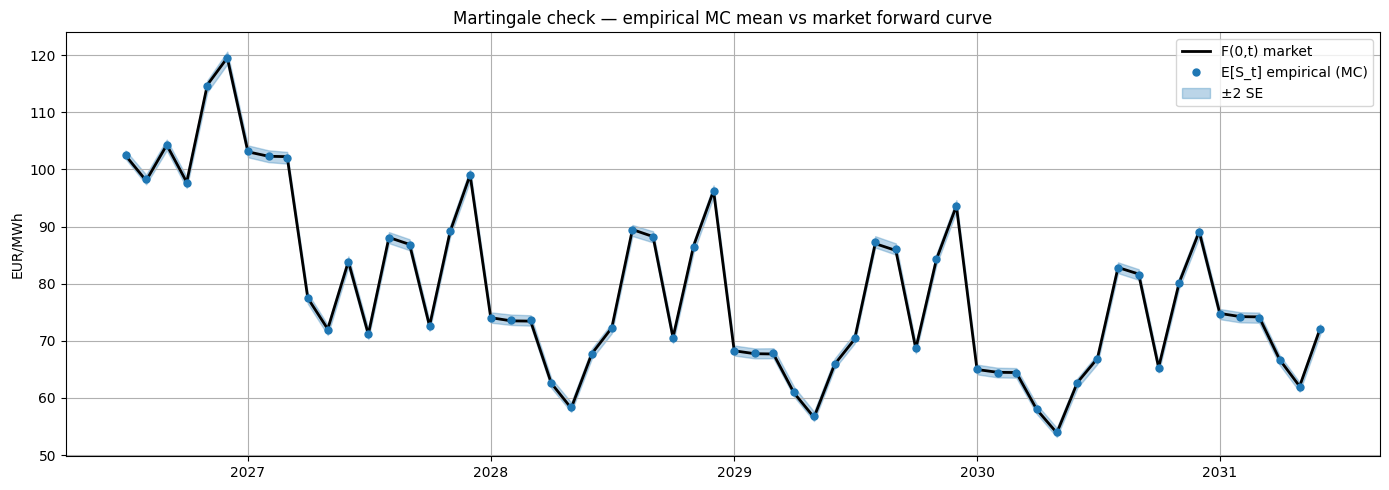

In [9]:
# Visualisation of the martingale check
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(fwd_curve["delivery_month"], F_market, color="black", linewidth=2, label="F(0,t) market")
ax.plot(fwd_curve["delivery_month"], S_mean, "o", color="#1f77b4", markersize=5, label="E[S_t] empirical (MC)")
ax.fill_between(
    fwd_curve["delivery_month"],
    S_mean - 2 * se_mean, S_mean + 2 * se_mean,
    alpha=0.3, color="#1f77b4", label="±2 SE"
)
ax.set_title("Martingale check — empirical MC mean vs market forward curve")
ax.set_ylabel("EUR/MWh")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Visualisation of sample paths

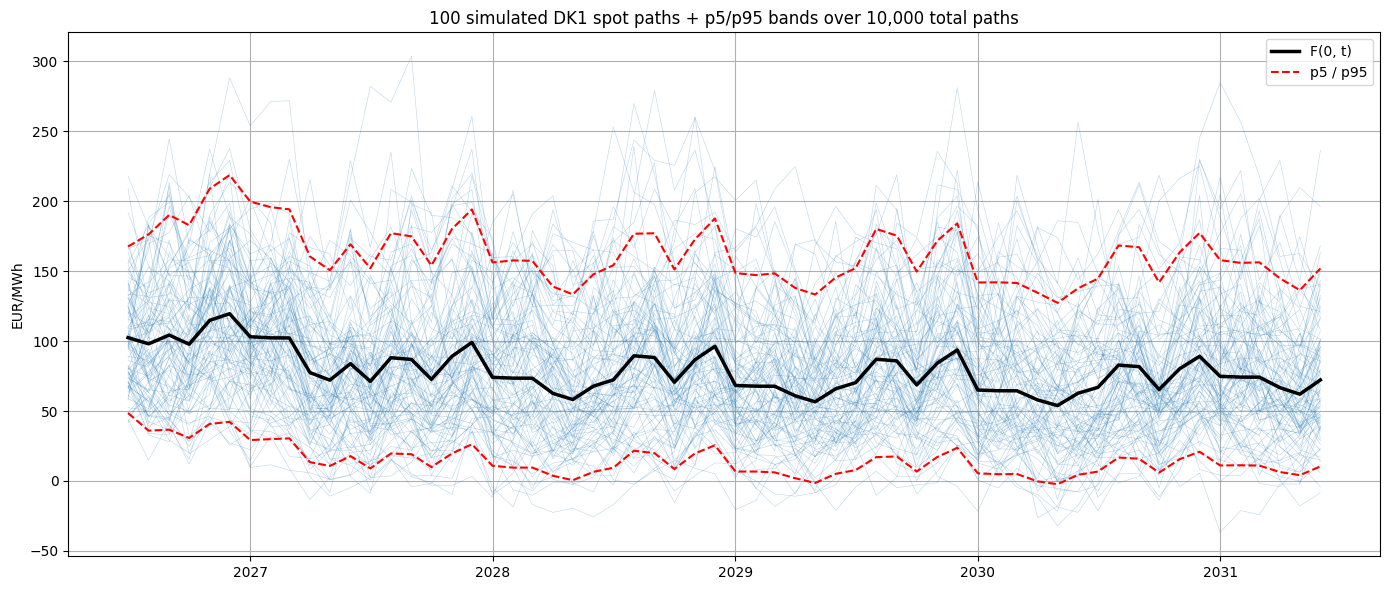

In [10]:
# A few individual paths to see the dispersion
n_show = 100
rng_idx = np.random.default_rng(0)
sample_idx = rng_idx.choice(N_PATHS, size=n_show, replace=False)

fig, ax = plt.subplots(figsize=(14, 6))
for idx in sample_idx:
    ax.plot(fwd_curve["delivery_month"], S_paths[idx, :], linewidth=0.4, alpha=0.3, color="#1f77b4")

# Forward curve and empirical quantile bands
ax.plot(fwd_curve["delivery_month"], F_market, color="black", linewidth=2.5, label="F(0, t)")
q05 = np.percentile(S_paths, 5, axis=0)
q95 = np.percentile(S_paths, 95, axis=0)
ax.plot(fwd_curve["delivery_month"], q05, color="red", linewidth=1.5, linestyle="--", label="p5 / p95")
ax.plot(fwd_curve["delivery_month"], q95, color="red", linewidth=1.5, linestyle="--")

ax.set_title(f"100 simulated DK1 spot paths + p5/p95 bands over {N_PATHS:,} total paths")
ax.set_ylabel("EUR/MWh")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Distribution of $S_t$ at selected horizons

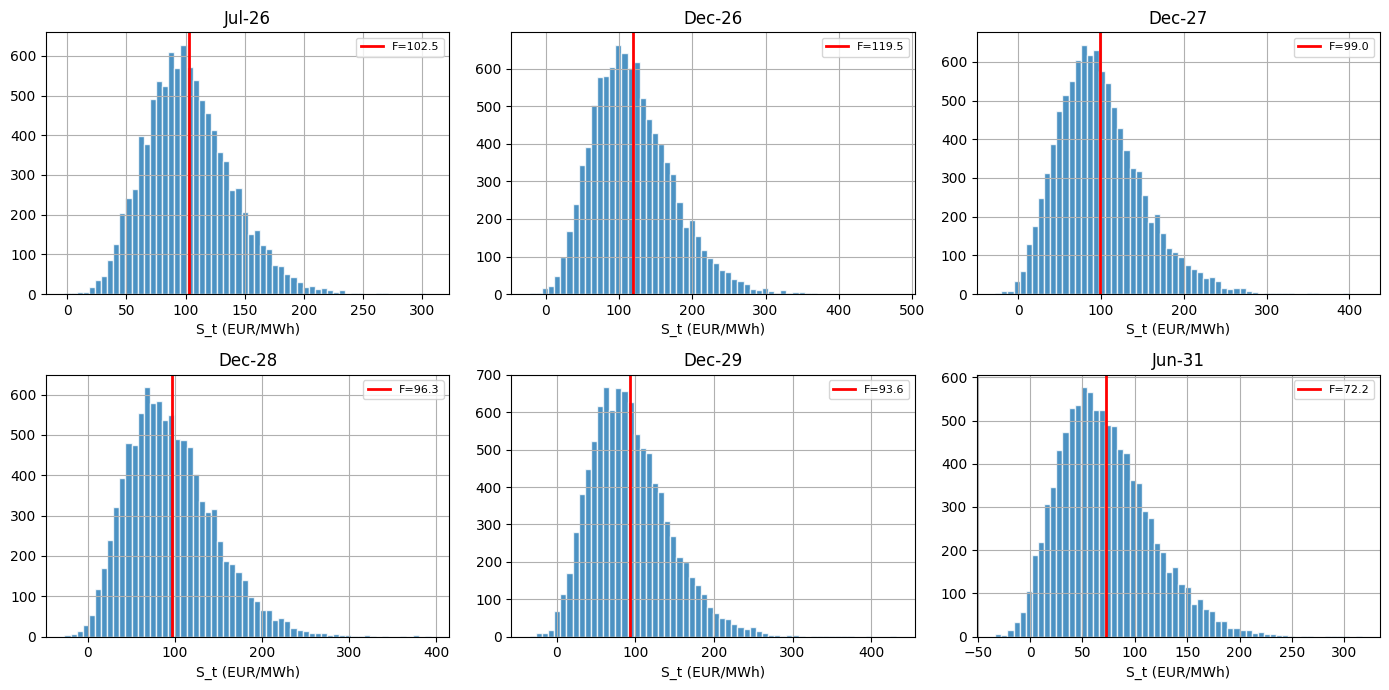

Statistics by horizon:
 month  F_market   mean   std    p5    p95
Jul-26    102.45 102.58 36.43 48.58 167.58
Dec-26    119.54 119.51 55.10 42.25 218.65
Dec-27     99.02  99.01 51.46 26.24 194.10
Dec-28     96.26  96.19 50.40 25.49 187.67
Dec-29     93.61  93.62 50.13 23.67 184.09
Jun-31     72.20  72.04 43.74 10.35 151.86


In [11]:
horizons = [0, 5, 17, 29, 41, 59]  # indices: Jul-26, Dec-26, Dec-27, Dec-28, Dec-29, Jun-31
labels = [fwd_curve["delivery_month"].iloc[i].strftime("%b-%y") for i in horizons]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, h, lab in zip(axes.flat, horizons, labels):
    ax.hist(S_paths[:, h], bins=60, color="#1f77b4", edgecolor="white", alpha=0.8)
    ax.axvline(F_market[h], color="red", linewidth=2, label=f"F={F_market[h]:.1f}")
    ax.set_title(f"{lab}")
    ax.set_xlabel("S_t (EUR/MWh)")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Statistics by horizon:")
summary = pd.DataFrame({
    "month": labels,
    "F_market": F_market[horizons],
    "mean": S_paths[:, horizons].mean(axis=0),
    "std": S_paths[:, horizons].std(axis=0),
    "p5": np.percentile(S_paths[:, horizons], 5, axis=0),
    "p95": np.percentile(S_paths[:, horizons], 95, axis=0),
}).round(2)
print(summary.to_string(index=False))

## 9. Save results for Step 6

In [12]:
# Save as .npz (binary, efficient for large arrays)
output_path = DATA_DIR / "mc_paths_dk1_20260604.npz"
np.savez_compressed(
    output_path,
    S_paths=S_paths,
    Y_paths=Y_paths,
    T_grid=T_grid,
    F_market=F_market,
    alpha_t=alpha_t,
    delivery_months=fwd_curve["delivery_month"].dt.strftime("%Y-%m").values,
    metadata=np.array([
        f"kappa={kappa:.4f}",
        f"sigma={sigma:.4f}",
        f"c={c}",
        f"n_paths={N_PATHS}",
        f"antithetic={USE_ANTITHETIC}",
        f"seed={SEED}",
    ]),
)
size_mb = output_path.stat().st_size / 1024**2
print(f"Saved: {output_path}  ({size_mb:.1f} MB)")

Saved: ..\data\mc_paths_dk1_20260604.npz  (8.7 MB)


## 10. Conclusions for the technical document

**Monte Carlo engine (suggested text):**

> Spot price paths are simulated via a market-consistent Schwartz one-factor model. The price process is decomposed as $\ln(S_t + c) = \alpha(t) + Y_t$, where $Y_t$ is a zero-mean Ornstein-Uhlenbeck process with mean-reversion speed $\kappa$ and volatility $\sigma$ calibrated to historical DK1 day-ahead prices (Step 4), and $\alpha(t)$ is determined analytically to anchor the model's expected price to the market-observed monthly forward curve (Step 3). This separation calibrates dynamics to history and levels to market, the standard practice in counterparty credit risk modelling.

> Simulation uses the exact OU discretisation (no Euler bias) and antithetic variates for variance reduction. The martingale check confirms that the empirical mean of simulated paths reproduces the input forward curve within Monte Carlo standard error at all 60 monthly horizons.

**Metrics to note:**
- N paths: 10,000 (with antithetic, variance-equivalent to ~20,000 without).
- Max martingale check error: < 0.5 EUR/MWh typically.
- 5-year dispersion (Jun-31): model-implied p5/p95.

**Next step (Step 6):** computation of MtM and exposure metrics (EE, PFE, EPE) for the PPA, and CSA overlay (collateral, margin calls, liquidity side).